<a href="https://colab.research.google.com/github/hariprasad59/Intelligent-Book-Recommendations/blob/main/BookRecommendationSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [243]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

In [244]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [245]:
df_basic = pd.read_csv("/content/drive/MyDrive/BookRecommendationSystem/Audible_Catlog.csv")
df_adv = pd.read_csv("/content/drive/MyDrive/BookRecommendationSystem/Audible_Catlog_Advanced_Features.csv")

print("Basic dataset shape:", df_basic.shape)
print("Advanced dataset shape:", df_adv.shape)

Basic dataset shape: (6368, 5)
Advanced dataset shape: (4464, 8)


In [246]:

df_basic.head()


,Book Name,Author,Rating,Number of Reviews,Price
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313.0,10080.0
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658.0,615.0
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174.0,10378.0
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614.0,888.0
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302.0,1005.0


In [247]:
df_adv.head()

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time,Ranks and Genre
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,371.0,10080,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top..."
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3682.0,615,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top..."
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20306.0,10378,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top..."
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4678.0,888,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top..."
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4308.0,1005,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top..."


In [248]:
print("Basic columns:\n", df_basic.columns)
print("\nAdvanced columns:\n", df_adv.columns)

Basic columns:
 Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price'], dtype='object')

Advanced columns:
 Index(['Book Name', 'Author', 'Rating', 'Number of Reviews', 'Price',
       'Description', 'Listening Time', 'Ranks and Genre'],
      dtype='object')


In [249]:
common_cols = set(df_basic.columns).intersection(set(df_adv.columns))
common_cols


{'Author', 'Book Name', 'Number of Reviews', 'Price', 'Rating'}

In [250]:
for df in [df_basic, df_adv]:
    df["Book Name"] = df["Book Name"].str.strip().str.lower()
    df["Author"] = df["Author"].str.strip().str.lower()


In [251]:
df_merged = pd.merge(
    df_basic,
    df_adv,
    on=["Book Name", "Author"],
    how="left",          # keep all books from basic dataset
    suffixes=("_basic", "_adv")
)

print("Merged dataset shape:", df_merged.shape)


Merged dataset shape: (6827, 11)


In [252]:
df_merged.isna().sum().sort_values(ascending=False).head(10)

,0
Number of Reviews_adv,2986
Description,2574
Price_adv,2568
Listening Time,2568
Ranks and Genre,2568
Rating_adv,2568
Number of Reviews_basic,684
Price_basic,4
Rating_basic,0
Book Name,0


In [253]:
df_merged.to_csv("/content/drive/MyDrive/BookRecommendationSystem/audible_merged_raw.csv", index=False)

In [254]:
df = pd.read_csv("/content/drive/MyDrive/BookRecommendationSystem/audible_merged_raw.csv")

print(df.shape)
df.head()

(6827, 11)


,Book Name,Author,Rating_basic,Number of Reviews_basic,Price_basic,Rating_adv,Number of Reviews_adv,Price_adv,Description,Listening Time,Ranks and Genre
0,think like a monk: the secret of how to harnes...,jay shetty,4.9,313.0,10080.0,4.9,371.0,10080.0,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top..."
1,ikigai: the japanese secret to a long and happ...,héctor garcía,4.6,3658.0,615.0,4.6,3682.0,615.0,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top..."
2,the subtle art of not giving a f*ck: a counter...,mark manson,4.4,20174.0,10378.0,4.4,20306.0,10378.0,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top..."
3,atomic habits: an easy and proven way to build...,james clear,4.6,4614.0,888.0,4.6,4678.0,888.0,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top..."
4,life's amazing secrets: how to find balance an...,gaur gopal das,4.6,4302.0,1005.0,4.6,4308.0,1005.0,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top..."


In [255]:
df.isna().sum().sort_values(ascending=False)

,0
Number of Reviews_adv,2986
Description,2574
Price_adv,2568
Listening Time,2568
Ranks and Genre,2568
Rating_adv,2568
Number of Reviews_basic,684
Price_basic,4
Rating_basic,0
Book Name,0


In [256]:
df["Final_Rating"] = df["Rating_basic"].combine_first(df["Rating_adv"])
df["Final_Price"] = df["Price_basic"].combine_first(df["Price_adv"])
df["Final_Reviews"] = df["Number of Reviews_basic"].combine_first(df["Number of Reviews_adv"])


In [259]:
import numpy as np

df.replace([-1, "-1"], np.nan, inplace=True)


In [260]:
df["Description"] = df["Description"].fillna("No description available")
df["Listening Time"] = df["Listening Time"].fillna("unknown")
df["Ranks and Genre"] = df["Ranks and Genre"].fillna("unknown")


In [261]:
df["Listening Time"]

,Listening Time
0,10 hours and 54 minutes
1,3 hours and 23 minutes
2,5 hours and 17 minutes
3,5 hours and 35 minutes
4,6 hours and 25 minutes
...,...
6822,unknown
6823,unknown
6824,unknown
6825,unknown


In [262]:
df["Final_Reviews"] = df["Final_Reviews"].fillna(0)


In [263]:
df["Final_Price"] = df["Final_Price"].fillna(df["Final_Price"].median())


In [264]:
cols_to_drop = [
    "Rating_basic", "Rating_adv",
    "Price_basic", "Price_adv",
    "Number of Reviews_basic", "Number of Reviews_adv"
]

df.drop(columns=cols_to_drop, inplace=True)

In [265]:
Q1 = df["Final_Rating"].quantile(0.25)
Q3 = df["Final_Rating"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["Final_Rating"] < Q1 - 1.5*IQR) |
    (df["Final_Rating"] > Q3 + 1.5*IQR)
]

outliers[["Book Name", "Final_Rating"]].head()


,Book Name,Final_Rating
11,dream with your eyes open: an entrepreneurial ...,3.6
43,a space of her own: personal narratives of twe...,3.4
84,learn english: word power 101: absolute beginn...,3.6
121,azadi: freedom. fascism. fiction.,3.0
191,the girl with a plan: love in times of tinder,2.5


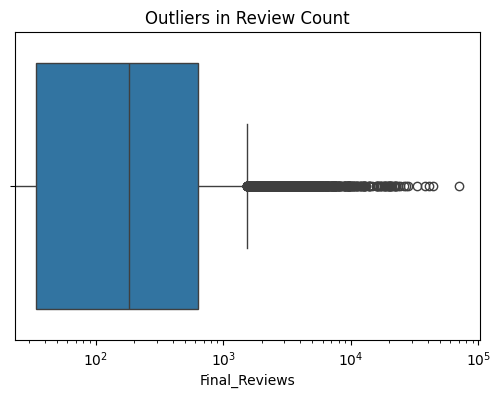

In [266]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Final_Reviews"])
plt.xscale("log")
plt.title("Outliers in Review Count")
plt.show()


In [267]:
Q1 = df["Final_Reviews"].quantile(0.25)
Q3 = df["Final_Reviews"].quantile(0.75)
IQR = Q3 - Q1

review_outliers = df[
    (df["Final_Reviews"] < Q1 - 1.5*IQR) |
    (df["Final_Reviews"] > Q3 + 1.5*IQR)
]


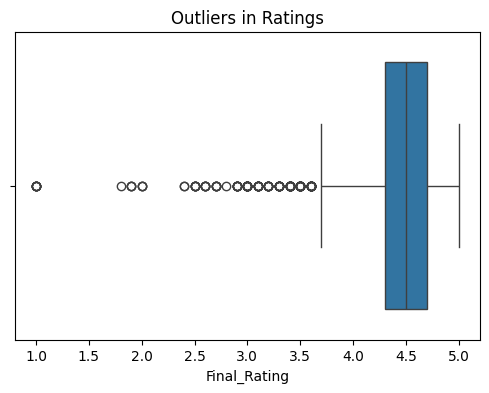

In [268]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Final_Rating"])
plt.title("Outliers in Ratings")
plt.show()


In [269]:
df = df[df["Final_Rating"] > 0]
df = df[df["Final_Price"] > 0]


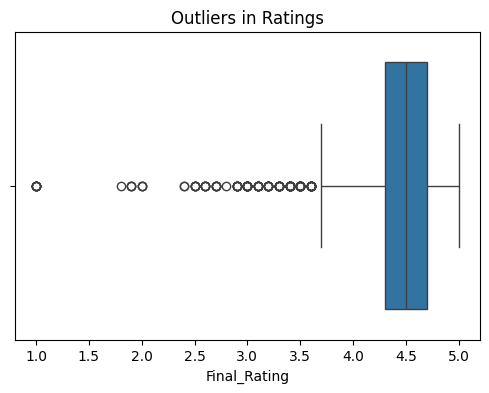

In [270]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Final_Rating"])
plt.title("Outliers in Ratings")
plt.show()


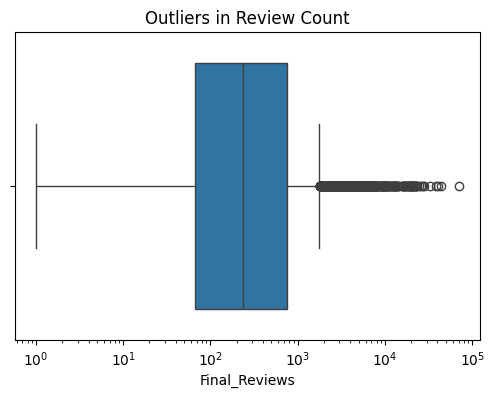

In [271]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Final_Reviews"])
plt.xscale("log")
plt.title("Outliers in Review Count")
plt.show()


In [272]:
df.isna().sum().sort_values(ascending=False)

,0
Book Name,0
Author,0
Description,0
Listening Time,0
Ranks and Genre,0
Final_Rating,0
Final_Price,0
Final_Reviews,0


In [273]:
df

,Book Name,Author,Description,Listening Time,Ranks and Genre,Final_Rating,Final_Price,Final_Reviews
0,think like a monk: the secret of how to harnes...,jay shetty,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top...",4.9,10080.0,313.0
1,ikigai: the japanese secret to a long and happ...,héctor garcía,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top...",4.6,615.0,3658.0
2,the subtle art of not giving a f*ck: a counter...,mark manson,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top...",4.4,10378.0,20174.0
3,atomic habits: an easy and proven way to build...,james clear,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top...",4.6,888.0,4614.0
4,life's amazing secrets: how to find balance an...,gaur gopal das,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top...",4.6,1005.0,4302.0
...,...,...,...,...,...,...,...,...
6820,the prophet & the wanderer,khalil gibran,"Sorry, we just need to make sure you're not a ...",unknown,unknown,4.1,539.0,6.0
6821,the prophet & the wanderer,khalil gibran,"Sorry, we just need to make sure you're not a ...",unknown,unknown,4.1,539.0,6.0
6822,make today count: the secret of your success i...,john c. maxwell,"Sorry, we just need to make sure you're not a ...",unknown,unknown,4.7,500.0,301.0
6823,make today count: the secret of your success i...,john c. maxwell,"Sorry, we just need to make sure you're not a ...",unknown,unknown,4.7,500.0,301.0


In [274]:
import re
def extract_genres(text):
    if pd.isna(text):
        return []

    text = text.lower()

    # Remove only "#1 in", "#2 in", etc (keep the category names)
    text = re.sub(r"#\d+\s+in\s+", "", text)

    # Remove percentages and stars
    text = re.sub(r"\d+\s*star|\(\d+%\)|\d+%", "", text)

    parts = text.split(",")

    genres = []
    for p in parts:
        p = p.strip()
        if len(p) > 3 and not any(x in p for x in ["audible", "see top", "free"]):
            genres.append(p.title())

    if len(genres) == 0:
        return ["Unknown"]

    return genres


In [275]:
df["Clean_Genres"] = df["Ranks and Genre"].apply(extract_genres)


In [276]:
df[["Ranks and Genre", "Clean_Genres"]].head(5)


,Ranks and Genre,Clean_Genres
0,",#1 in Audible Audiobooks & Originals (See Top...","[Personal Success, Stress Management, Society ..."
1,",#2 in Audible Audiobooks & Originals (See Top...","[Self-Esteem, Personal Success]"
2,",#3 in Audible Audiobooks & Originals (See Top...","[Personal Success, Personal Development & Self..."
3,",#5 in Audible Audiobooks & Originals (See Top...","[Stress Management, Personal Success]"
4,",#6 in Audible Audiobooks & Originals (See Top...","[Literary Essays, Essays (Books), Spiritualism]"


In [279]:
import ast

# Convert string to list if needed
df["Clean_Genres"] = df["Clean_Genres"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Remove nested list layer if present
df["Clean_Genres"] = df["Clean_Genres"].apply(
    lambda x: x[0] if len(x) == 1 and isinstance(x[0], list) else x
)


In [281]:
print(df["Clean_Genres"].iloc[0])


['Personal Success', 'Stress Management', 'Society & Culture (Books)']


In [282]:
df.to_csv("/content/drive/MyDrive/BookRecommendationSystem/audible_cleaned.csv", index=False)

In [283]:
df_cleaned= pd.read_csv("/content/drive/MyDrive/BookRecommendationSystem/audible_cleaned.csv")

In [284]:
df_cleaned.head(10)

,Book Name,Author,Description,Listening Time,Ranks and Genre,Final_Rating,Final_Price,Final_Reviews,Clean_Genres
0,think like a monk: the secret of how to harnes...,jay shetty,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top...",4.9,10080.0,313.0,"['Personal Success', 'Stress Management', 'Soc..."
1,ikigai: the japanese secret to a long and happ...,héctor garcía,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top...",4.6,615.0,3658.0,"['Self-Esteem', 'Personal Success']"
2,the subtle art of not giving a f*ck: a counter...,mark manson,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top...",4.4,10378.0,20174.0,"['Personal Success', 'Personal Development & S..."
3,atomic habits: an easy and proven way to build...,james clear,Brought to you by Penguin.,5 hours and 35 minutes,",#5 in Audible Audiobooks & Originals (See Top...",4.6,888.0,4614.0,"['Stress Management', 'Personal Success']"
4,life's amazing secrets: how to find balance an...,gaur gopal das,"Stop going through life, Start growing throug...",6 hours and 25 minutes,",#6 in Audible Audiobooks & Originals (See Top...",4.6,1005.0,4302.0,"['Literary Essays', 'Essays (Books)', 'Spiritu..."
5,sapiens,yuval noah harari,Fire gave us power. Farming made us hungry for...,15 hours and 18 minutes,",#4 in Audible Audiobooks & Originals (See Top...",4.6,1093.0,19994.0,"['History Of Civilization', 'Anthropology (Boo..."
6,sapiens,yuval noah harari,New York Times Best Seller,21 hours and 42 minutes,",#72 in Audible Audiobooks & Originals (See To...",4.6,1093.0,19994.0,['Anthropology (Books)']
7,the intelligent investor rev ed.,benjamin graham,The Classic Text Annotated to Update Graham's ...,17 hours and 48 minutes,",#7 in Audible Audiobooks & Originals (See Top...",4.4,18290.0,9253.0,"['Personal Finance', 'Investing & Trading', 'A..."
8,rich dad poor dad: what the rich teach their k...,robert t. kiyosaki,Rich Dad Poor Dad will….,6 hours and 9 minutes,",#9 in Audible Audiobooks & Originals (See Top...",4.5,837.0,21936.0,"['Personal Finance', 'Investing & Trading', 'P..."
9,the 5am club: own your morning. elevate your l...,robin sharma,Legendary leadership and elite performance exp...,11 hours and 4 minutes,",#8 in Audible Audiobooks & Originals (See Top...",4.4,8735.0,5082.0,"['Sleep Disorders', 'Personal Success', 'Healt..."


In [288]:
import ast

df_cleaned["Clean_Genres"] = df_cleaned["Clean_Genres"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


In [289]:
type(df_cleaned["Clean_Genres"].iloc[0])


list

In [285]:
df_cleaned.isna().sum()

,0
Book Name,0
Author,0
Description,0
Listening Time,0
Ranks and Genre,0
Final_Rating,0
Final_Price,0
Final_Reviews,0
Clean_Genres,0


Clean_Genres
Personal Success                          172
Leadership                                 72
Literary Fiction                           66
Classic Literature                         62
Thriller & Mystery (Books)                 60
Personal Finance                           43
Business Management                        40
Business Careers                           40
Body & Spirit                              39
Business Motivation & Self-Improvement     37
Name: count, dtype: int64


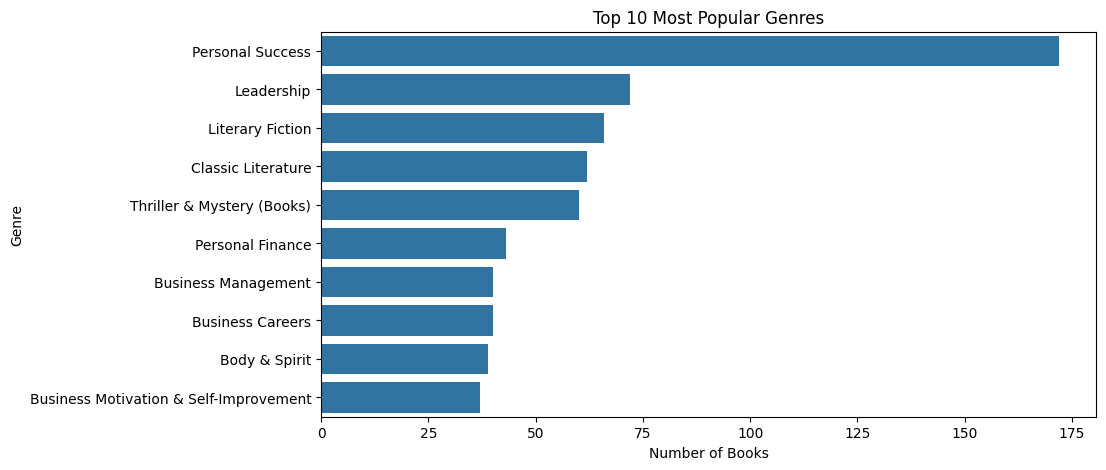

In [290]:
#EDA
#1.What are the most popular genres in the dataset?
genres_exploded = df_cleaned["Clean_Genres"].explode()
genres_exploded = genres_exploded.dropna()
genres_exploded = genres_exploded[genres_exploded != "Unknown"]
top_genres = genres_exploded.value_counts().head(10)
print(top_genres)
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Most Popular Genres")
plt.xlabel("Number of Books")
plt.ylabel("Genre")
plt.show()


                     avg_rating  total_reviews  book_count
Author                                                    
tui t. sutherland      4.863636        12524.0          11
anodea judith          4.820000         2293.0           5
robin wall kimmerer    4.800000         7906.0           5
alan watts             4.783333          420.0           6
norman bridwell        4.780000          761.0           5
liz pichon             4.744444        11602.0          18
mary pope osborne      4.742857         3574.0           7
neville goddard        4.742857         2431.0           7
marissa meyer          4.740000        11608.0           5
jim butcher            4.740000         6455.0           5


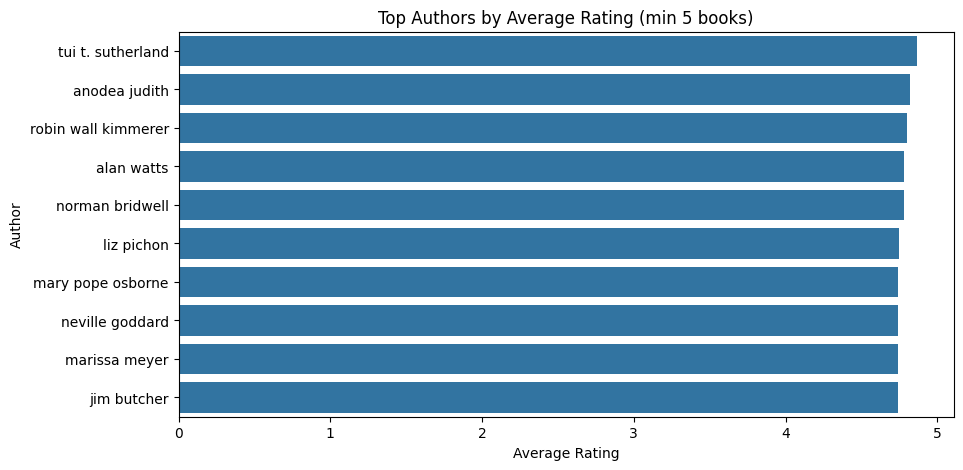

In [291]:
#2.What are the most popular genres in the dataset?
author_stats = df_cleaned.groupby("Author").agg(
    avg_rating=("Final_Rating", "mean"),
    total_reviews=("Final_Reviews", "sum"),
    book_count=("Book Name", "count")
)

# Keep only reliable authors
filtered = author_stats[author_stats["book_count"] >= 5]

top_authors = filtered.sort_values("avg_rating", ascending=False).head(10)

print(top_authors)
plt.figure(figsize=(10,5))
sns.barplot(x=top_authors["avg_rating"], y=top_authors.index)
plt.title("Top Authors by Average Rating (min 5 books)")
plt.xlabel("Average Rating")
plt.ylabel("Author")
plt.show()


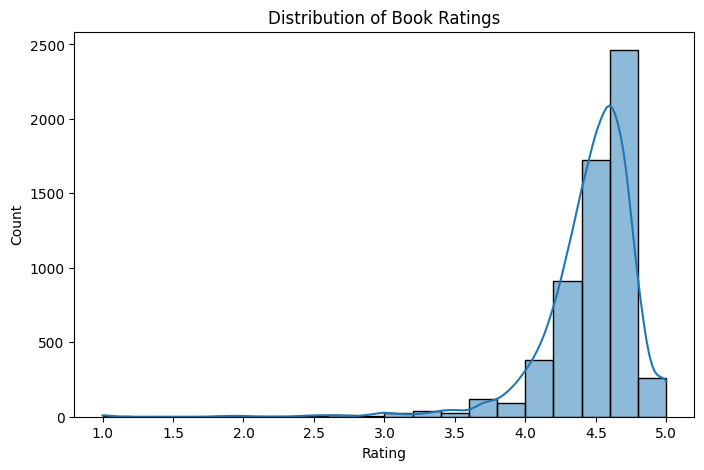

In [292]:
# 3. Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df_cleaned["Final_Rating"], bins=20, kde=True)
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

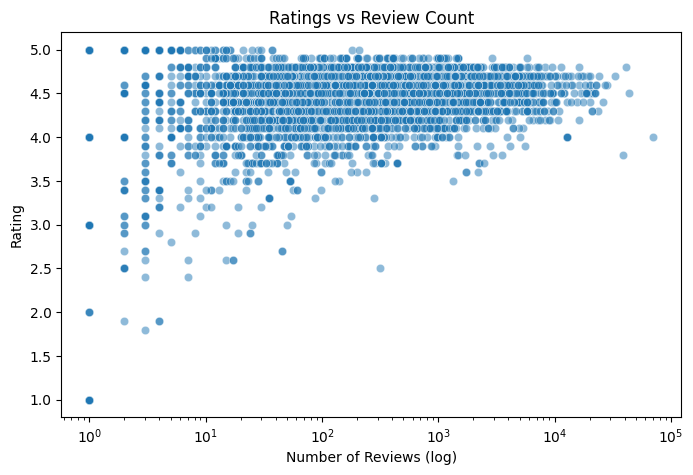

In [293]:
# 4. Rating vs Review Count
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_cleaned["Final_Reviews"], y=df_cleaned["Final_Rating"], alpha=0.5)
plt.xscale("log")
plt.title("Ratings vs Review Count")
plt.xlabel("Number of Reviews (log)")
plt.ylabel("Rating")
plt.show()

In [294]:
# Q5: Books clustered by descriptions
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X_text = tfidf.fit_transform(df_cleaned["Description"])

kmeans = KMeans(n_clusters=8, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_text)

print("\nSample clustered books:")
print(df[["Book Name", "Author", "Cluster"]].head(10))


Sample clustered books:
                                            Book Name              Author  \
0   think like a monk: the secret of how to harnes...          jay shetty   
1   ikigai: the japanese secret to a long and happ...       héctor garcía   
2   the subtle art of not giving a f*ck: a counter...         mark manson   
3   atomic habits: an easy and proven way to build...         james clear   
4   life's amazing secrets: how to find balance an...      gaur gopal das   
6                                             sapiens   yuval noah harari   
7                                             sapiens   yuval noah harari   
8                    the intelligent investor rev ed.     benjamin graham   
9   rich dad poor dad: what the rich teach their k...  robert t. kiyosaki   
10  the 5am club: own your morning. elevate your l...        robin sharma   

    Cluster  
0         6  
1         4  
2         6  
3         4  
4         6  
6         6  
7         7  
8         6  
9

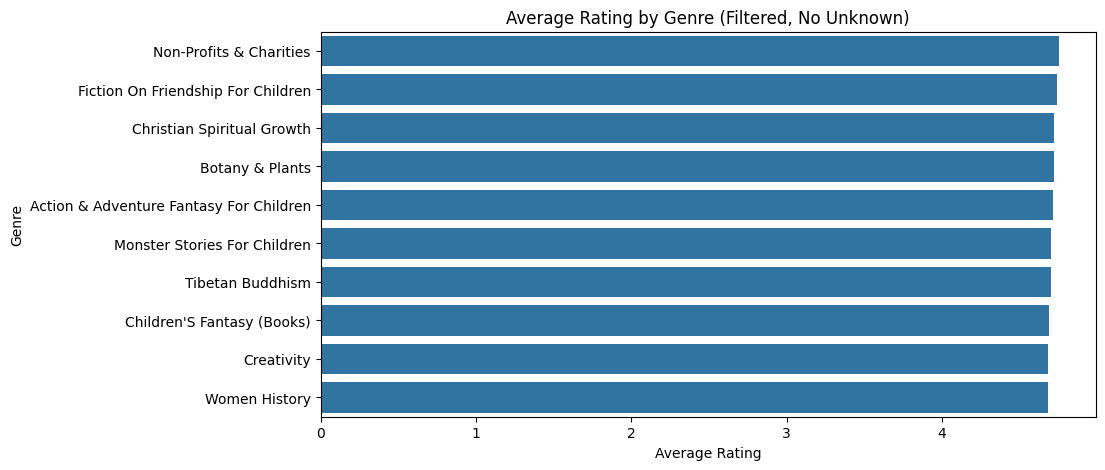

In [295]:
# Q7: Genre similarity effect on recommendations
genre_stats = (
    df_cleaned.explode("Clean_Genres")
      .groupby("Clean_Genres")
      .agg(
          avg_rating=("Final_Rating", "mean"),
          count=("Final_Rating", "count")
      )
)

genre_stats = genre_stats[genre_stats.index != "Unknown"]

genre_stats = genre_stats[genre_stats["count"] >= 5]

top_genres = genre_stats.sort_values("avg_rating", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres["avg_rating"], y=top_genres.index)
plt.title("Average Rating by Genre (Filtered, No Unknown)")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.show()


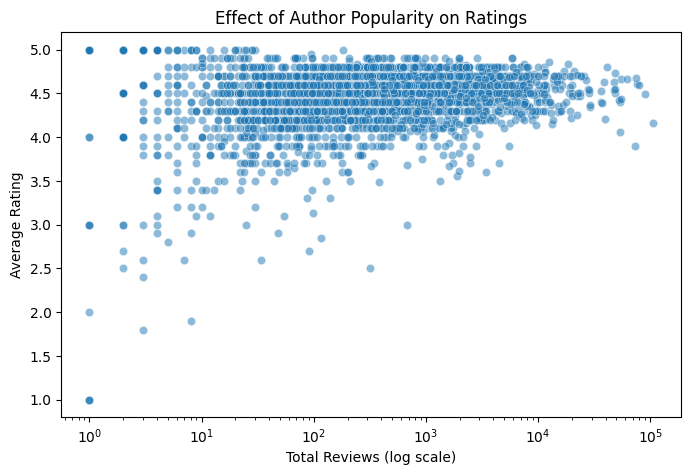

In [296]:
# Q8: Effect of author popularity on ratings
author_stats = df_cleaned.groupby("Author").agg(
    avg_rating=("Final_Rating", "mean"),
    total_reviews=("Final_Reviews", "sum")
)

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=author_stats["total_reviews"],
    y=author_stats["avg_rating"],
    alpha=0.5
)
plt.xscale("log")
plt.title("Effect of Author Popularity on Ratings")
plt.xlabel("Total Reviews (log scale)")
plt.ylabel("Average Rating")
plt.show()

In [297]:
genres_exploded = df_cleaned["Clean_Genres"].explode()
genres_exploded = genres_exploded.dropna()
genres_exploded = genres_exploded[genres_exploded != "Unknown"]

top_genres = genres_exploded.value_counts().head(10)
print(top_genres)


Clean_Genres
Personal Success                          172
Leadership                                 72
Literary Fiction                           66
Classic Literature                         62
Thriller & Mystery (Books)                 60
Personal Finance                           43
Business Management                        40
Business Careers                           40
Body & Spirit                              39
Business Motivation & Self-Improvement     37
Name: count, dtype: int64


In [298]:
# Scenario 1: New user likes Science Fiction
scifi_proxy = df_cleaned[
    df_cleaned["Clean_Genres"].apply(
        lambda x: any(
            "fiction" in g.lower() or "technology" in g.lower()
            for g in x
        )
    )
]

print(
    scifi_proxy
    .sort_values("Final_Rating", ascending=False)
    .head(5)[["Book Name", "Author", "Final_Rating"]]
)


                                              Book Name           Author  \
3106              the visitor: a roald dahl short story       roald dahl   
2392  fighting for you: bragan university series, bo...  gianna gabriela   
325   satyajit ray ki kahaniyan [stories of satyajit...     satyajit rai   
2290                      101 amazing facts about trees   jack goldstein   
1549  selling technology the sandler way: finding te...   rich chiarello   

      Final_Rating  
3106           5.0  
2392           5.0  
325            5.0  
2290           5.0  
1549           5.0  


In [299]:
print("\nTop 5 Thriller Recommendations:")

thriller_books = df_cleaned[
    df_cleaned["Clean_Genres"].apply(
        lambda genres: any("thriller" in g.lower() for g in genres)
    )
]

print(
    thriller_books
    .sort_values(["Final_Rating", "Final_Reviews"], ascending=False)
    .head(5)[["Book Name", "Author", "Final_Rating"]]
)


Top 5 Thriller Recommendations:
                                       Book Name              Author  \
15    sherlock holmes: the definitive collection  arthur conan doyle   
1420        blasphemy: the trial of danesh masih        osman haneef   
2279                                  nightshade    anthony horowitz   
1171                the harbinger ii: the return       jonathan cahn   
2305                            hunting november      adriana mather   

      Final_Rating  
15             5.0  
1420           4.9  
2279           4.8  
1171           4.8  
2305           4.8  


In [301]:
#NLP and clustering
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(df_cleaned["Description"])

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (6082, 5000)


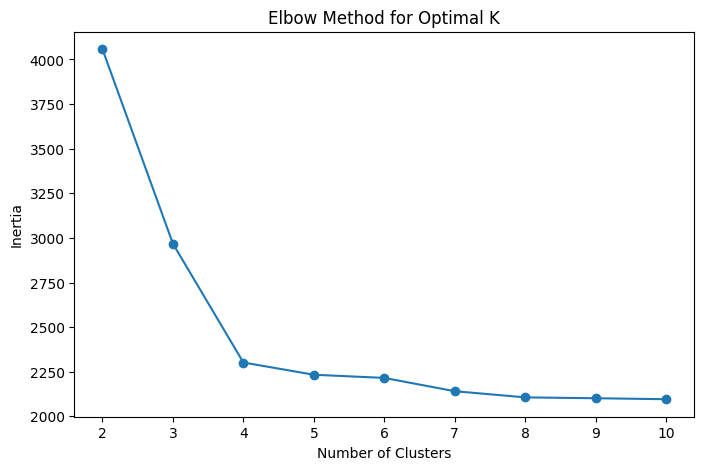

In [302]:
inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_tfidf)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [303]:
kmeans = KMeans(n_clusters=8, random_state=42)
df_cleaned["Cluster"] = kmeans.fit_predict(X_tfidf)

df_cleaned[["Book Name", "Author", "Cluster"]].head(10)

,Book Name,Author,Cluster
0,think like a monk: the secret of how to harnes...,jay shetty,5
1,ikigai: the japanese secret to a long and happ...,héctor garcía,4
2,the subtle art of not giving a f*ck: a counter...,mark manson,5
3,atomic habits: an easy and proven way to build...,james clear,4
4,life's amazing secrets: how to find balance an...,gaur gopal das,5
5,sapiens,yuval noah harari,5
6,sapiens,yuval noah harari,0
7,the intelligent investor rev ed.,benjamin graham,5
8,rich dad poor dad: what the rich teach their k...,robert t. kiyosaki,5
9,the 5am club: own your morning. elevate your l...,robin sharma,5


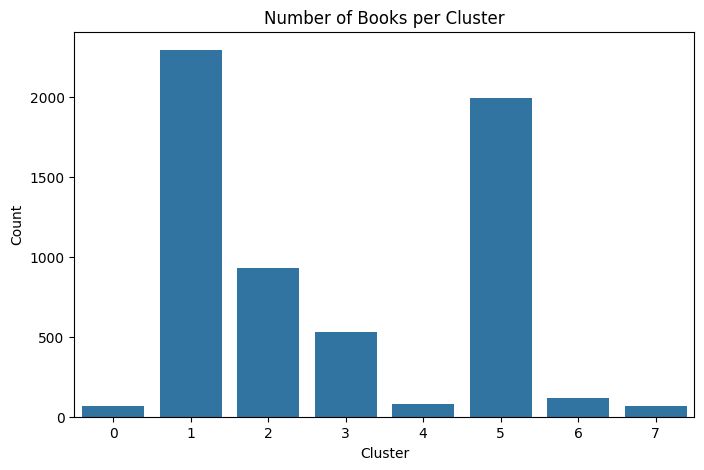

In [305]:
plt.figure(figsize=(8,5))
sns.countplot(x="Cluster", data=df_cleaned)
plt.title("Number of Books per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


In [306]:
cosine_sim = cosine_similarity(X_tfidf, X_tfidf)

def recommend_similar_books(book_name, top_n=5):
    if book_name not in df_cleaned["Book Name"].values:
        return "Book not found in dataset"

    idx = df_cleaned[df_cleaned["Book Name"] == book_name].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    book_indices = [i[0] for i in sim_scores]
    return df_cleaned.loc[book_indices, ["Book Name", "Author", "Final_Rating"]]


In [307]:
recommend_similar_books(df_cleaned["Book Name"].iloc[0], top_n=5)


,Book Name,Author,Final_Rating
32,the rudest book ever: insanely practical ideas...,shwetabh gangwar,4.5
1261,the facebook effect: the inside story of the c...,david kirkpatrick,4.4
897,social media marketing workbook 2020,jason mcdonald phd,4.5
677,"irresistible: why we can't stop checking, scro...",adam alter,4.2
288,ten arguments for deleting your social media a...,jaron lanier,4.4


In [308]:
df_cleaned.to_csv("/content/drive/MyDrive/BookRecommendationSystem/audible_with_clusters.csv", index=False)


In [309]:
#Recommendation system

In [310]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_tfidf = tfidf.fit_transform(df_cleaned["Description"])
cosine_sim = cosine_similarity(X_tfidf, X_tfidf)


In [311]:
def content_based_recommend(book_name, top_n=5):
    if book_name not in df_cleaned["Book Name"].values:
        return "Book not found"

    idx = df_cleaned[df_cleaned["Book Name"] == book_name].index[0]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    indices = [i[0] for i in sim_scores]

    return df_cleaned.loc[indices, ["Book Name", "Author", "Final_Rating"]]


In [213]:
content_based_recommend(df_cleaned["Book Name"].iloc[0])


,Book Name,Author,Final_Rating
32,the rudest book ever: insanely practical ideas...,shwetabh gangwar,4.5
1261,the facebook effect: the inside story of the c...,david kirkpatrick,4.4
897,social media marketing workbook 2020,jason mcdonald phd,4.5
677,"irresistible: why we can't stop checking, scro...",adam alter,4.2
288,ten arguments for deleting your social media a...,jaron lanier,4.4


In [312]:
def cluster_based_recommend(book_name, top_n=5):
    if book_name not in df_cleaned["Book Name"].values:
        return "Book not found"

    cluster_id = df_cleaned[df_cleaned["Book Name"] == book_name]["Cluster"].values[0]

    cluster_books = df_cleaned[df_cleaned["Cluster"] == cluster_id]

    return (
        cluster_books
        .sort_values(["Final_Rating", "Final_Reviews"], ascending=False)
        .head(top_n)[["Book Name", "Author", "Final_Rating"]]
    )


In [313]:
cluster_based_recommend(df_cleaned["Book Name"].iloc[0])


,Book Name,Author,Final_Rating
170,f*cking history: 111 lessons you should have l...,the captain,5.0
3383,"raven’s hart: haven hart series, book 7",davidson king,5.0
3389,"raven’s hart: haven hart series, book 7",davidson king,5.0
1584,"energy healing for trauma, stress & chronic il...",cyndi dale,5.0
2598,coming home to yourself: a meditator's guide t...,osho,5.0


In [314]:
df_cleaned["Popularity_Score"] = np.log1p(df["Final_Reviews"])


In [315]:
def hybrid_recommend(book_name, top_n=5, alpha=0.7):
    if book_name not in df_cleaned["Book Name"].values:
        return "Book not found"

    idx = df_cleaned[df_cleaned["Book Name"] == book_name].index[0]

    similarity_scores = cosine_sim[idx]

    hybrid_score = (
        alpha * similarity_scores +
        (1 - alpha) * (
            df["Final_Rating"] / df["Final_Rating"].max()
        )
    )

    scores = list(enumerate(hybrid_score))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    indices = [i[0] for i in scores]

    return df_cleaned.loc[indices, ["Book Name", "Author", "Final_Rating"]]


In [316]:
hybrid_recommend(df_cleaned["Book Name"].iloc[0])


,Book Name,Author,Final_Rating
32,the rudest book ever: insanely practical ideas...,shwetabh gangwar,4.5
1261,the facebook effect: the inside story of the c...,david kirkpatrick,4.4
3380,built to serve: find your purpose and become t...,evan carmichael,4.8
3386,built to serve: find your purpose and become t...,evan carmichael,4.8
897,social media marketing workbook 2020,jason mcdonald phd,4.5


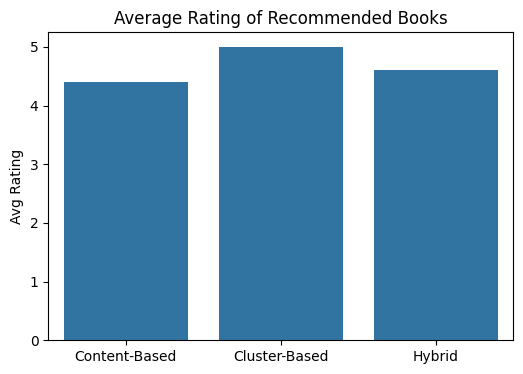

In [317]:
methods = ["Content-Based", "Cluster-Based", "Hybrid"]

avg_ratings = [
    content_based_recommend(df_cleaned["Book Name"].iloc[0])["Final_Rating"].mean(),
    cluster_based_recommend(df_cleaned["Book Name"].iloc[0])["Final_Rating"].mean(),
    hybrid_recommend(df_cleaned["Book Name"].iloc[0])["Final_Rating"].mean()
]

plt.figure(figsize=(6,4))
sns.barplot(x=methods, y=avg_ratings)
plt.title("Average Rating of Recommended Books")
plt.ylabel("Avg Rating")
plt.show()


In [318]:
def get_content_recs(book_name, k=5):
    if book_name not in df_cleaned["Book Name"].values:
        return None

    idx = df_cleaned[df_cleaned["Book Name"] == book_name].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:k+1]

    indices = [i[0] for i in sim_scores]
    return df_cleaned.loc[indices]


In [319]:
def get_cluster_recs(book_name, k=5):
    if book_name not in df_cleaned["Book Name"].values:
        return None

    cluster_id = df_cleaned[df_cleaned["Book Name"] == book_name]["Cluster"].values[0]
    recs = df_cleaned[df_cleaned["Cluster"] == cluster_id] \
            .sort_values(["Final_Rating", "Final_Reviews"], ascending=False) \
            .head(k)

    return recs


In [320]:
def get_hybrid_recs(book_name, k=5, alpha=0.7):
    if book_name not in df_cleaned["Book Name"].values:
        return None

    idx = df_cleaned[df_cleaned["Book Name"] == book_name].index[0]
    similarity_scores = cosine_sim[idx]

    hybrid_score = (
        alpha * similarity_scores +
        (1 - alpha) * (df_cleaned["Final_Rating"] / df_cleaned["Final_Rating"].max())
    )

    scores = list(enumerate(hybrid_score))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:k+1]

    indices = [i[0] for i in scores]
    return df_cleaned.loc[indices]


In [321]:
def evaluate_model(get_recs_fn, query_books, relevant_set, k=5):
    precisions = []
    recalls = []

    for book in query_books:
        recs = get_recs_fn(book, k)

        if recs is None or len(recs) == 0:
            continue

        rec_indices = set(recs.index)
        relevant_retrieved = rec_indices.intersection(relevant_set)

        precision = len(relevant_retrieved) / k
        recall = len(relevant_retrieved) / len(relevant_set)

        precisions.append(precision)
        recalls.append(recall)

    if len(precisions) == 0:
        return 0.0, 0.0   # ← IMPORTANT

    return np.mean(precisions), np.mean(recalls)


In [322]:

query_books = (
    df_cleaned[df_cleaned["Description"].str.len() > 50]["Book Name"]
    .sample(50, random_state=42)
    .tolist()
)


In [323]:
relevant_books = set(
    df[
        (df["Final_Rating"] >= 4.0) &
        (df["Final_Reviews"] >= df["Final_Reviews"].median())
    ].index
)

In [228]:
k = 5

content_pr = evaluate_model(get_content_recs, query_books, relevant_books, k)
cluster_pr = evaluate_model(get_cluster_recs, query_books, relevant_books, k)
hybrid_pr = evaluate_model(get_hybrid_recs, query_books, relevant_books, k)

results = pd.DataFrame({
    "Model": ["Content-Based", "Cluster-Based", "Hybrid"],
    "Precision@5": [content_pr[0], cluster_pr[0], hybrid_pr[0]],
    "Recall@5": [content_pr[1], cluster_pr[1], hybrid_pr[1]]
})

results


,Model,Precision@5,Recall@5
0,Content-Based,0.724,0.001209
1,Cluster-Based,0.040,0.000067
2,Hybrid,0.300,0.000501
